# What should this listener hear next? Building a music recommender

Which artists would a Last.fm user like, given what they already play? This notebook builds three recommenders on real listening data and measures them properly:

1. **Popularity**: recommend what everyone listens to (the baseline every model must beat).
2. **Item-item collaborative filtering**: recommend artists whose listeners overlap with the artists you already play.
3. **Implicit ALS matrix factorisation**, written from scratch with NumPy: learns a short taste profile for every listener and every artist.

Each listener's artists are split into training, validation and test sets, models are tuned on the validation part, and the final scores come from the **test artists the models never saw**. The question the test answers: when we hide 20% of someone's artists, how many of them show up in the top 10 recommendations?

**Data:** [HetRec 2011 Last.fm](https://grouplens.org/datasets/hetrec-2011/) from GroupLens: 1,892 users, 17,632 artists and the number of plays of each artist by each user (about 2.6 MB, downloaded on first run into `LASTFM_DIR`). The dataset keeps each user's **50 most played artists**, so nobody has more than 50.

In [1]:
import io
import os
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.decomposition import PCA, TruncatedSVD

DATA_DIR = Path(os.environ.get("LASTFM_DIR", "lastfm_data"))
DATA_DIR.mkdir(exist_ok=True)
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
rng = np.random.default_rng(42)

## 1. Load the listening data

In [2]:
zip_path = DATA_DIR / "hetrec2011-lastfm-2k.zip"
if not zip_path.exists():
    urllib.request.urlretrieve("https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip", zip_path)
with zipfile.ZipFile(zip_path) as z:
    plays = pd.read_csv(z.open("user_artists.dat"), sep="\t")
    artists = pd.read_csv(io.TextIOWrapper(z.open("artists.dat"), encoding="utf-8", errors="replace"), sep="\t",
                          usecols=["id", "name"]).set_index("id").name
plays = plays.rename(columns={"userID": "user", "artistID": "artist", "weight": "plays"})

stats = pd.Series({"users": plays.user.nunique(), "artists": plays.artist.nunique(), "user-artist pairs": len(plays),
                   "density": f"{len(plays) / (plays.user.nunique() * plays.artist.nunique()):.2%}",
                   "artists per user (median)": int(plays.groupby("user").size().median()),
                   "most played artist": artists[plays.groupby("artist").plays.sum().idxmax()]})
stats

users                                  1892
artists                               17632
user-artist pairs                     92834
density                               0.28%
artists per user (median)                50
most played artist           Britney Spears
dtype: object

Real listening data is **extremely sparse**: each user plays a tiny fraction of the catalogue, and a few artists get most of the attention. That is why a recommender is hard, and why plain popularity is a strong baseline.

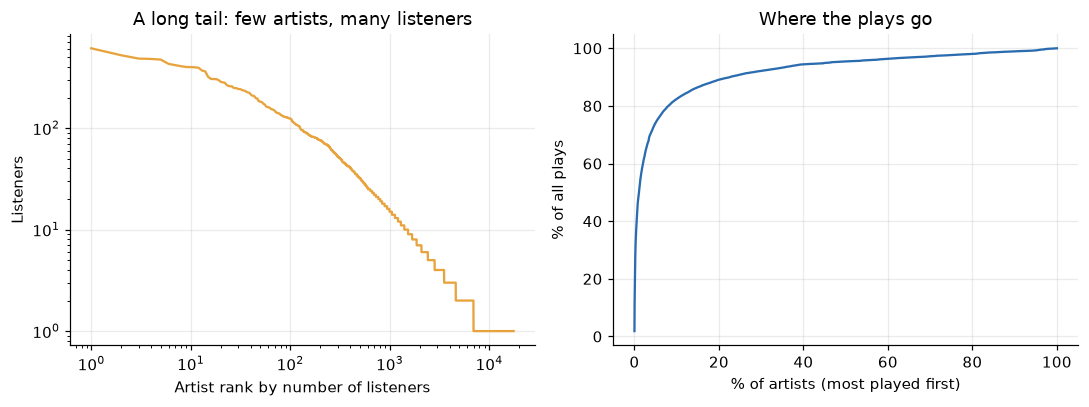

,listeners,plays,name
artist,,,
89,611,1291387,Lady Gaga
289,522,2393140,Britney Spears
288,484,905423,Rihanna
227,480,662116,The Beatles
300,473,532545,Katy Perry


In [3]:
per_artist = plays.groupby("artist").agg(listeners=("user", "nunique"), plays=("plays", "sum")).sort_values("listeners", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(np.arange(1, len(per_artist) + 1), per_artist.listeners.to_numpy(), color=AMBER)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Artist rank by number of listeners")
axes[0].set_ylabel("Listeners")
axes[0].set_title("A long tail: few artists, many listeners")
share = per_artist.plays.cumsum() / per_artist.plays.sum()
axes[1].plot(np.arange(1, len(share) + 1) / len(share) * 100, share * 100, color=BLUE)
axes[1].set_xlabel("% of artists (most played first)")
axes[1].set_ylabel("% of all plays")
axes[1].set_title("Where the plays go")
fig.tight_layout()
plt.show()
per_artist.head(5).join(artists)

## 2. Prepare the data and split it

Artists listened to by fewer than 5 users carry too little signal to learn from, so they are dropped. Plays are turned into a **confidence** with `log(1 + plays)`, so one artist played 10,000 times does not drown out everything else. For every user with at least 10 artists, a random 70% of their artists go to training, 10% to validation and 20% to testing.

In [4]:
MIN_LISTENERS = 5
keep = per_artist.index[per_artist.listeners >= MIN_LISTENERS]
data = plays[plays.artist.isin(keep)].copy()
user_ids = np.sort(data.user.unique())
artist_ids = np.sort(data.artist.unique())
u_index = {u: i for i, u in enumerate(user_ids)}
a_index = {a: i for i, a in enumerate(artist_ids)}
data["u"] = data.user.map(u_index)
data["a"] = data.artist.map(a_index)
data["conf"] = np.log1p(data.plays)
n_users, n_items = len(user_ids), len(artist_ids)

counts = data.groupby("u").size()
eligible = counts[counts >= 10].index
data["split"] = "train"
for u, group in data[data.u.isin(eligible)].groupby("u"):
    order = rng.permutation(group.index.to_numpy())
    n_test, n_valid = int(round(0.2 * len(order))), int(round(0.1 * len(order)))
    data.loc[order[:n_test], "split"] = "test"
    data.loc[order[n_test:n_test + n_valid], "split"] = "valid"

print(f"{n_users:,} users x {n_items:,} artists after filtering; "
      + ", ".join(f"{k}: {v:,}" for k, v in data.split.value_counts().items()))

def matrix(splits):
    d = data[data.split.isin(splits)]
    return sp.csr_matrix((d.conf.to_numpy(), (d.u.to_numpy(), d.a.to_numpy())), shape=(n_users, n_items))

X_train = matrix(["train"])
X_train_valid = matrix(["train", "valid"])
truth_valid = data[data.split == "valid"].groupby("u").a.apply(set)
truth_test = data[data.split == "test"].groupby("u").a.apply(set)
item_popularity = np.asarray((X_train_valid > 0).sum(axis=0)).ravel()

1,881 users x 2,828 artists after filtering; train: 50,061, test: 14,230, valid: 7,135


## 3. How a recommender is scored

For each user the models score every artist, the artists they already know are removed, and the top 10 are compared with the hidden ones:

- **Recall@10**: of the hidden artists, what share was in the top 10?
- **Precision@10**: of the 10 recommendations, how many were hidden artists?
- **NDCG@10**: like precision, but a hit at rank 1 counts more than a hit at rank 10.
- **Coverage**: how much of the catalogue ever gets recommended (a model that suggests the same 10 artists to everybody scores near zero).
- **Novelty**: the average number of listeners of the recommended artists (lower = less obvious picks).

In [5]:
K = 10

def evaluate(score_matrix, seen, truth):
    """score_matrix: users x items scores. seen: sparse matrix of artists to exclude. truth: user -> hidden artists."""
    users = np.array(sorted(truth.index))
    scores = np.array(score_matrix[users], dtype=np.float32)
    seen_rows = seen[users].tocoo()
    scores[seen_rows.row, seen_rows.col] = -np.inf
    top = np.argpartition(-scores, K, axis=1)[:, :K]
    top = np.take_along_axis(top, np.argsort(-np.take_along_axis(scores, top, axis=1), axis=1), axis=1)
    discounts = 1 / np.log2(np.arange(2, K + 2))
    rec, prec, ndcg = [], [], []
    for row, u in zip(top, users):
        hidden = truth[u]
        hits = np.array([a in hidden for a in row])
        rec.append(hits.sum() / len(hidden))
        prec.append(hits.mean())
        ideal = discounts[:min(len(hidden), K)].sum()
        ndcg.append((hits * discounts).sum() / ideal)
    return {"recall@10": np.mean(rec), "precision@10": np.mean(prec), "ndcg@10": np.mean(ndcg),
            "coverage": len(np.unique(top)) / n_items, "novelty": item_popularity[top].mean()}

popularity_scores = np.tile(np.asarray((X_train > 0).sum(axis=0)).ravel().astype(np.float32), (n_users, 1))
pd.Series(evaluate(popularity_scores, X_train, truth_valid)).round(4).to_frame("popularity baseline (validation)")

,popularity baseline (validation)
recall@10,0.0825
precision@10,0.0359
ndcg@10,0.0668
coverage,0.0085
novelty,360.2336


## 4. Model 1 and 2: popularity and item-item collaborative filtering

**Item-item filtering** measures how similar two artists are by how much their audiences overlap (cosine similarity between their listener columns). To recommend, it adds up the similarity of every candidate artist to the artists the user already plays, keeping only each artist's `k` closest neighbours.

In [6]:
def item_item_scores(X, neighbours=50):
    B = (X > 0).astype(np.float32).tocsc()
    norms = np.sqrt(np.asarray(B.sum(axis=0)).ravel()) + 1e-9
    sim = (B.T @ B).toarray() / np.outer(norms, norms)           # cosine similarity of listener sets
    np.fill_diagonal(sim, 0)
    cutoff = -np.partition(-sim, neighbours, axis=1)[:, neighbours][:, None]
    sim[sim < cutoff] = 0                                            # keep each artist's closest neighbours only
    return (X > 0).astype(np.float32) @ sim, sim

rows = []
for neighbours in [10, 30, 100, 300]:
    s, _ = item_item_scores(X_train, neighbours)
    rows.append({"neighbours": neighbours, **evaluate(s, X_train, truth_valid)})
knn_grid = pd.DataFrame(rows).set_index("neighbours")
BEST_K = int(knn_grid["ndcg@10"].idxmax())
print("best neighbourhood size:", BEST_K)
knn_grid.round(4)

best neighbourhood size: 300


,recall@10,precision@10,ndcg@10,coverage,novelty
neighbours,,,,,
10,0.1842,0.0739,0.1496,0.5244,164.6590
30,0.1981,0.0787,0.1631,0.4993,168.5610
100,0.2202,0.0872,0.1803,0.4480,175.0918
300,0.2214,0.0877,0.1831,0.3985,185.1099


## 5. Model 3: implicit ALS matrix factorisation, from scratch

Instead of comparing artists one by one, matrix factorisation gives **every user and every artist a short vector** (here a few dozen numbers) so that the dot product of a user's vector and an artist's vector predicts how much they would enjoy it. *Alternating least squares* learns the vectors by alternating two simple steps: hold the artist vectors fixed and solve for each user's vector exactly, then hold the users fixed and solve for each artist. Because a missing play does not mean dislike, every unseen pair is treated as a weak negative and every observed play as a positive whose weight grows with `alpha * log(1 + plays)` (the method of Hu, Koren and Volinsky for implicit feedback).

In [7]:
def als(X, factors=32, reg=0.5, alpha=15.0, iterations=12, seed=0):
    """Implicit-feedback ALS. X: sparse users x items matrix of confidences (log1p plays)."""
    r = np.random.default_rng(seed)
    n_u, n_i = X.shape
    U = r.normal(0, 0.1, (n_u, factors))
    V = r.normal(0, 0.1, (n_i, factors))
    Xr, Xc = X.tocsr(), X.T.tocsr()

    def solve(fixed, sparse_rows, n_rows):
        YtY = fixed.T @ fixed + reg * np.eye(factors)
        out = np.zeros((n_rows, factors))
        for i in range(n_rows):
            start, end = sparse_rows.indptr[i], sparse_rows.indptr[i + 1]
            idx, vals = sparse_rows.indices[start:end], sparse_rows.data[start:end]
            if len(idx) == 0:
                continue
            Y = fixed[idx]
            c = alpha * vals                                           # extra confidence of the observed pairs
            A = YtY + (Y.T * c) @ Y
            b = Y.T @ (1 + c)
            out[i] = np.linalg.solve(A, b)
        return out

    for _ in range(iterations):
        U = solve(V, Xr, n_u)
        V = solve(U, Xc, n_i)
    return U, V

rows = []
for factors in [8, 16, 32, 64]:
    for alpha in [1.0, 3.0, 5.0, 15.0]:
        U, V = als(X_train, factors=factors, alpha=alpha)
        rows.append({"factors": factors, "alpha": alpha, **evaluate(U @ V.T, X_train, truth_valid)})
als_grid = pd.DataFrame(rows).set_index(["factors", "alpha"])
BEST_F, BEST_ALPHA = als_grid["ndcg@10"].idxmax()
print("best setting:", BEST_F, "factors, alpha", BEST_ALPHA)
als_grid.round(4)

best setting: 32 factors, alpha 1.0


recall@10  precision@10  ndcg@10  coverage   novelty
factors alpha                                                      
8       1.0       0.1926        0.0802   0.1659    0.0937  189.6729
        3.0       0.2064        0.0844   0.1721    0.1471  170.8152
        5.0       0.2055        0.0835   0.1684    0.1856  156.3997
        15.0      0.1788        0.0723   0.1404    0.2854  118.6393
16      1.0       0.2208        0.0903   0.1851    0.1637  164.8872
        3.0       0.2208        0.0897   0.1811    0.2309  146.7479
        5.0       0.2147        0.0871   0.1730    0.2733  135.8833
        15.0      0.1756        0.0706   0.1347    0.3837  106.0724
32      1.0       0.2299        0.0930   0.1896    0.2373  144.4716
        3.0       0.2223        0.0898   0.1801    0.3147  135.5516
        5.0       0.2119        0.0853   0.1694    0.3564  129.7398
        15.0      0.1721        0.0688   0.1337    0.4360  116.1429
64      1.0       0.2135        0.0848   0.1751    0.3380  119.2390
        3.0       0.1973        0.0781   0.1623    0.4240  115.6538
        5.0       0.1898        0.0748   0.1549    0.4597  113.6707
        15.0      0.1770        0.0691   0.1406    0.5255  109.2539

## 6. The final comparison on the hidden test artists

Now the tuned models are refitted on training **plus** validation artists and scored on the test artists, which nothing has seen. A plain truncated-SVD factorisation (no confidence weights) is added as a fourth reference.

In [8]:
final = {}
pop = np.tile(np.asarray((X_train_valid > 0).sum(axis=0)).ravel().astype(np.float32), (n_users, 1))
final["Popularity"] = evaluate(pop, X_train_valid, truth_test)
s_knn, similarity = item_item_scores(X_train_valid, BEST_K)
final["Item-item CF"] = evaluate(s_knn, X_train_valid, truth_test)
svd = TruncatedSVD(n_components=BEST_F, random_state=0).fit(X_train_valid)
final["Truncated SVD"] = evaluate(svd.transform(X_train_valid) @ svd.components_, X_train_valid, truth_test)
U, V = als(X_train_valid, factors=int(BEST_F), alpha=float(BEST_ALPHA))
final["Implicit ALS"] = evaluate(U @ V.T, X_train_valid, truth_test)
results = pd.DataFrame(final).T
results.round(4)

,recall@10,precision@10,ndcg@10,coverage,novelty
Popularity,0.0806,0.0688,0.0865,0.0092,357.0760
Item-item CF,0.2242,0.1778,0.2516,0.3731,182.9113
Truncated SVD,0.1885,0.1553,0.2121,0.1262,147.6223
Implicit ALS,0.2411,0.1946,0.2651,0.2546,139.4019


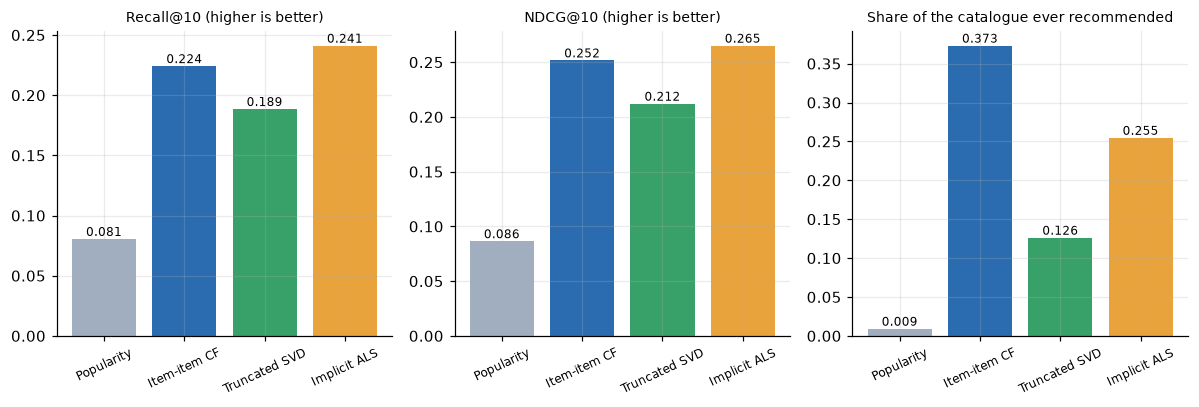

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
colors = [GREY, BLUE, "#38a169", AMBER]
for ax, metric, title in zip(axes, ["recall@10", "ndcg@10", "coverage"], ["Recall@10 (higher is better)", "NDCG@10 (higher is better)", "Share of the catalogue ever recommended"]):
    ax.bar(results.index, results[metric], color=colors)
    for x, v in enumerate(results[metric]):
        ax.text(x, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="x", rotation=25, labelsize=8)
fig.tight_layout()
plt.show()

## 7. Does it work for light listeners as well as heavy ones?

Recommenders usually have more to go on for users with a long history. The users are grouped by how many artists they had in the training data and the best model's recall is shown for each group.

In [10]:
train_counts = np.asarray((X_train_valid > 0).sum(axis=1)).ravel()
bands = pd.cut(train_counts, [0, 20, 30, 36, 1000], right=False, labels=["under 20", "20-29", "30-35", "36 or more"])
users = np.array(sorted(truth_test.index))
scores = (U @ V.T)[users].astype(np.float32)
seen = X_train_valid[users].tocoo()
scores[seen.row, seen.col] = -np.inf
top = np.argsort(-scores, axis=1)[:, :K]
per_user = pd.DataFrame({
    "band": bands[users],
    "recall": [np.mean([a in truth_test[u] for a in row]) * K / len(truth_test[u]) for row, u in zip(top, users)],
    "popularity_recall": [np.mean([a in truth_test[u] for a in np.argsort(-pop[0] * (np.asarray(X_train_valid[u].todense()).ravel() == 0))[:K]]) * K / len(truth_test[u]) for u in users],
})
by_band = per_user.groupby("band", observed=True).mean().round(3)
by_band.columns = ["ALS recall@10", "Popularity recall@10"]
by_band.assign(users=per_user.groupby("band", observed=True).size())

,ALS recall@10,Popularity recall@10,users
band,,,
under 20,0.191,0.034,172
20-29,0.193,0.042,424
30-35,0.226,0.068,623
36 or more,0.303,0.132,615


## 8. What has the model learned about music?

The artist vectors that ALS learned were never told anything about genres, yet artists that the same people listen to end up close together. The table lists the nearest neighbours of a few well-known artists by cosine similarity of their vectors, and the map flattens the vectors of the most popular artists to two dimensions.

In [11]:
names = artists.reindex(artist_ids)
name_to_item = {n: i for i, n in enumerate(names) if isinstance(n, str)}
Vn = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-9)
seeds = [s for s in ["Radiohead", "Metallica", "Lady Gaga", "Miles Davis", "Daft Punk", "Bob Marley"] if s in name_to_item]
pd.DataFrame({seed: [names.iloc[j] for j in np.argsort(-(Vn @ Vn[name_to_item[seed]]))[1:6]] for seed in seeds},
             index=[f"#{i}" for i in range(1, 6)])

,Radiohead,Metallica,Lady Gaga,Miles Davis,Daft Punk,Bob Marley
#1,Sigur Rós,Megadeth,Britney Spears,Charlie Parker,Justice,Damian Marley
#2,The Smashing Pumpkins,Iron Maiden,Katy Perry,Chet Baker,Phoenix,Rage Against the Machine
#3,The Beatles,System of a Down,Rihanna,Herbie Hancock,Chromeo,dead prez
#4,Coldplay,Pink Floyd,Christina Aguilera,Thelonious Monk,Gorillaz,Ponto de Equilíbrio
#5,Beck,Guns N' Roses,Ke$ha,Stan Getz,Calvin Harris,Peter Tosh


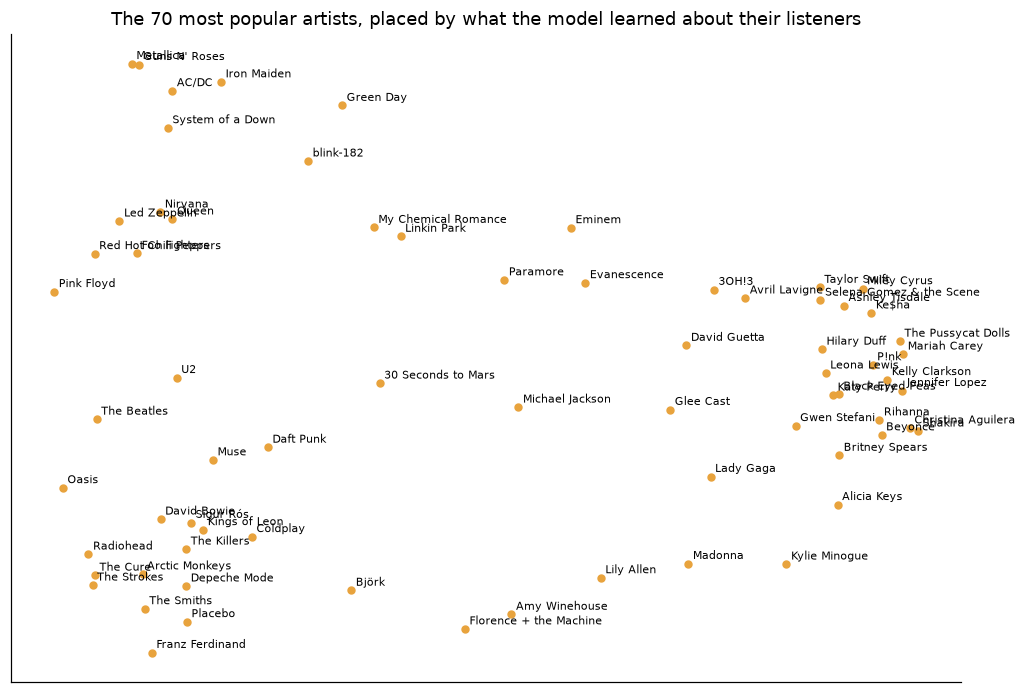

In [12]:
top_items = np.argsort(-item_popularity)[:70]
xy = PCA(n_components=2, random_state=0).fit_transform(Vn[top_items])
fig, ax = plt.subplots(figsize=(9.5, 6.4))
ax.scatter(xy[:, 0], xy[:, 1], s=20, color=AMBER)
for (x, y), item in zip(xy, top_items):
    ax.annotate(names.iloc[item], (x, y), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_title("The 70 most popular artists, placed by what the model learned about their listeners")
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
fig.tight_layout()
plt.show()

## What the results say

- **Popularity is a weak baseline here.** Recommending the same 10 popular artists to everybody finds only 8.1% of a user's hidden artists (recall@10) and touches 0.9% of the catalogue. Listening taste is more personal than that.
- **Personalisation roughly triples the hit rate.** On the hidden test artists, item-item filtering reaches a recall@10 of 0.224 and the factorisation (implicit ALS) 0.241, against 0.081 for popularity. In NDCG, which rewards putting hits near the top, ALS scores 0.265 against 0.252 for item-item filtering and 0.087 for popularity.
- **ALS wins on accuracy and on taste.** It beats item-item filtering by about 0.017 in recall, and its recommendations are less obvious: the artists it suggests have 139 listeners on average, against 183 for item-item and 357 for popularity. The price is that it spreads over less of the catalogue (25% of artists ever recommended, against 37% for item-item).
- **Confidence weighting needs care.** Treating heavy listening as strong evidence (`alpha` = 15) made recall worse (0.172 against 0.230 at `alpha` = 1 with 32 factors) because play counts are dominated by a few favourites. The best setting was at the edge of the grid searched, so an even smaller alpha might do slightly better. Bigger models were not better either: 64 factors scored below 32.
- **Plain truncated SVD, without the implicit-feedback treatment, does worse** (recall 0.189) and recommends from a narrow slice of the catalogue (13% coverage). The difference between SVD and ALS is exactly the modelling of missing plays as weak negatives with a confidence.
- **More history helps.** ALS recall rises from 0.191 for users with under 20 artists in the training data to 0.303 for users with 36 or more. Part of that is simply that heavier listeners have more hidden artists to find, which is why popularity also improves (0.034 to 0.132). The relative gain from personalisation is biggest for light listeners (5.6 times popularity against 2.3 times for the heaviest).
- **The model learned musical genres without being told.** The nearest neighbours of Metallica are Megadeth, Iron Maiden and System of a Down; of Lady Gaga, Britney Spears, Katy Perry and Rihanna; of Miles Davis, Charlie Parker, Chet Baker and Thelonious Monk; of Daft Punk, Justice, Phoenix and Chromeo. The map of the 70 most popular artists separates classic rock and indie, pop, metal and pop-punk into regions, using nothing but who listens to whom.

**Limits:** the dataset keeps each user's 50 most played artists, so it says what people play most, not everything they have heard; artists with fewer than 5 listeners were dropped, so the catalogue is 2,828 artists; the models see only play counts, no content, tags or time; the hidden artists are a stand-in for what the user would enjoy, because a recommendation that is good but was never played counts as a miss.

**Techniques covered:** sparse matrices, a per-user train / validation / test split, cosine item-item collaborative filtering, implicit-feedback ALS written in NumPy, truncated SVD, recall / precision / NDCG / coverage / novelty, PCA for visualisation.
